# Forecasting the Post-Pandemic Inflation Surge

This project compares conventional macroeconomic forecasting models for U.S. inflation. The main question is whether traditional models were able to predict inflation accurately after 2020, when inflation rose sharply following the COVID-19 pandemic.

The analysis uses monthly FRED data on the Consumer Price Index, unemployment rate, and federal funds rate. Inflation is calculated as the year-over-year percentage change in CPI. The models are trained using mostly pre-2020 data and evaluated on the post-2020 period.

## 1. Data Sources and Cleaning

This project uses three monthly macroeconomic series from FRED:

- Consumer Price Index for All Urban Consumers (`CPIAUCSL`)
- Unemployment Rate (`UNRATE`)
- Federal Funds Effective Rate (`FEDFUNDS`)

The three datasets are loaded from CSV files, converted to datetime format, and merged by date. Year-over-year inflation is then calculated as the 12-month percentage change in CPI.

The analysis focuses on observations from January 2000 onward.





In [74]:
# Step 1: Load and prepare FRED macroeconomic data


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load FRED datasets
cpi = pd.read_csv("CPIAUCSL_project.csv")
unrate = pd.read_csv("UNRATE_project.csv")
fedfunds = pd.read_csv("FEDFUNDS_project.csv")

# Convert dates to datetime format
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
unrate["observation_date"] = pd.to_datetime(unrate["observation_date"])
fedfunds["observation_date"] = pd.to_datetime(fedfunds["observation_date"])

# Merge datasets by date
data = cpi.merge(unrate, on="observation_date", how="inner")
data = data.merge(fedfunds, on="observation_date", how="inner")

# Sort by date
data = data.sort_values("observation_date")

# Calculate year-over-year inflation from CPI
data["inflation_yoy"] = data["CPIAUCSL"].pct_change(12, fill_method=None) * 100

# Keep proposal period: 2000 onward
data = data[data["observation_date"] >= "2000-01-01"]

# Drop missing values from inflation calculation
data = data.dropna().reset_index(drop=True)

# Rename date column for simplicity
data = data.rename(columns={"observation_date": "date"})

# Preview cleaned dataset
data.head()

,date,CPIAUCSL,UNRATE,FEDFUNDS,inflation_yoy
0,2000-01-01,169.3,4.0,5.45,2.792957
1,2000-02-01,170.0,4.1,5.73,3.217972
2,2000-03-01,171.0,4.0,5.85,3.762136
3,2000-04-01,170.9,3.8,6.02,3.013864
4,2000-05-01,171.2,4.0,6.27,3.132530


In [75]:
# Check final dataset information
print(data.shape)
print(data.head())
print(data.tail())
print(data.isnull().sum())

(314, 5)
        date  CPIAUCSL  UNRATE  FEDFUNDS  inflation_yoy
0 2000-01-01     169.3     4.0      5.45       2.792957
1 2000-02-01     170.0     4.1      5.73       3.217972
2 2000-03-01     171.0     4.0      5.85       3.762136
3 2000-04-01     170.9     3.8      6.02       3.013864
4 2000-05-01     171.2     4.0      6.27       3.132530
          date  CPIAUCSL  UNRATE  FEDFUNDS  inflation_yoy
309 2025-11-01   325.063     4.5      3.88       2.696444
310 2025-12-01   326.031     4.4      3.72       2.653304
311 2026-01-01   326.588     4.3      3.64       2.391201
312 2026-02-01   327.460     4.4      3.64       2.434004
313 2026-03-01   330.293     4.3      3.64       3.285958
date             0
CPIAUCSL         0
UNRATE           0
FEDFUNDS         0
inflation_yoy    0
dtype: int64


## 2. Forecasting Target and Train/Test Split

The forecasting target is next month's year-over-year inflation. This means that information available in one month is used to predict inflation in the following month.

The main training period is 2000–2019, while the testing period is 2020–2026. This split allows the project to evaluate whether models estimated using pre-pandemic data performed well during the post-pandemic inflation surge.

In [76]:
# Step 2: Create forecasting target and train/test split


# Forecast target: next month's year-over-year inflation.
# Example: information from January 2000 predicts inflation in February 2000.

model_data = data.copy()

# Target variable: next month's inflation
model_data["inflation_next"] = model_data["inflation_yoy"].shift(-1)

# Target date: the month being forecasted
model_data["target_date"] = model_data["date"].shift(-1)

# Drop last row because it has no next-month inflation value
model_data = model_data.dropna().reset_index(drop=True)

# Train on forecasts before 2020
train = model_data[model_data["target_date"] < "2020-01-01"]

# Test on forecasts from 2020 onward
test = model_data[model_data["target_date"] >= "2020-01-01"]

print("Training data:", train["target_date"].min(), "to", train["target_date"].max())
print("Testing data:", test["target_date"].min(), "to", test["target_date"].max())

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Training data: 2000-02-01 00:00:00 to 2019-12-01 00:00:00
Testing data: 2020-01-01 00:00:00 to 2026-03-01 00:00:00
Train shape: (239, 7)
Test shape: (74, 7)


In [77]:
# Preview the modeling dataset
model_data.head()

,date,CPIAUCSL,UNRATE,FEDFUNDS,inflation_yoy,inflation_next,target_date
0,2000-01-01,169.3,4.0,5.45,2.792957,3.217972,2000-02-01
1,2000-02-01,170.0,4.1,5.73,3.217972,3.762136,2000-03-01
2,2000-03-01,171.0,4.0,5.85,3.762136,3.013864,2000-04-01
3,2000-04-01,170.9,3.8,6.02,3.013864,3.132530,2000-05-01
4,2000-05-01,171.2,4.0,6.27,3.132530,3.734940,2000-06-01


## 3. Lagged Variables

Forecasting models often use lagged macroeconomic variables because inflation, unemployment, and interest rates tend to be persistent over time.

This section creates lagged values of inflation, unemployment, and the federal funds rate. These lagged variables allow the models to use recent economic conditions to forecast next month's inflation.

In [78]:
# Step 3: Create lag variables for forecasting models

model_data = model_data.copy()

# Lagged inflation variables
model_data["inflation_lag1"] = model_data["inflation_yoy"].shift(1)
model_data["inflation_lag2"] = model_data["inflation_yoy"].shift(2)
model_data["inflation_lag3"] = model_data["inflation_yoy"].shift(3)

# Lagged unemployment rate# and federal funds rate
model_data["UNRATE_lag1"] = model_data["UNRATE"].shift(1)
model_data["FEDFUNDS_lag1"] = model_data["FEDFUNDS"].shift(1)

# Drop rows with missing lag values
model_data = model_data.dropna().reset_index(drop=True)

# Re-create train/test split after adding lags
train = model_data[model_data["target_date"] < "2020-01-01"]
test = model_data[model_data["target_date"] >= "2020-01-01"]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

model_data.head()

Train shape: (236, 12)
Test shape: (74, 12)


,date,CPIAUCSL,UNRATE,FEDFUNDS,inflation_yoy,inflation_next,target_date,inflation_lag1,inflation_lag2,inflation_lag3,UNRATE_lag1,FEDFUNDS_lag1
0,2000-04-01,170.9,3.8,6.02,3.013864,3.132530,2000-05-01,3.762136,3.217972,2.792957,4.0,5.85
1,2000-05-01,171.2,4.0,6.27,3.132530,3.734940,2000-06-01,3.013864,3.762136,3.217972,3.8,6.02
2,2000-06-01,172.2,4.0,6.53,3.734940,3.599280,2000-07-01,3.132530,3.013864,3.762136,4.0,6.27
3,2000-07-01,172.7,4.0,6.54,3.599280,3.351287,2000-08-01,3.734940,3.132530,3.013864,4.0,6.53
4,2000-08-01,172.7,4.1,6.50,3.351287,3.456496,2000-09-01,3.599280,3.734940,3.132530,4.0,6.54


## 4. Forecast Evaluation Method

Forecast accuracy is measured using two standard error metrics:

- **Mean Absolute Error (MAE):** the average absolute difference between actual and predicted inflation.
- **Root Mean Squared Error (RMSE):** similar to MAE, but gives more weight to larger forecast errors.

Lower MAE and RMSE values indicate better forecasting performance.

In [79]:

# Step 4: Define forecast evaluation function


from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(y_true, y_pred, model_name):
    """
    Calculates standard forecast accuracy metrics.
    Lower MAE and RMSE mean better forecasting performance.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse
    }

## 5. Forecasting Models

This section estimates four forecasting models:

1. **Naive model:** next month's inflation equals current inflation.
2. **Autoregressive model:** next month's inflation is predicted using current and lagged inflation.
3. **Multivariate regression model:** inflation is predicted using inflation history, unemployment, and the federal funds rate.
4. **Vector autoregression model:** inflation, unemployment, and the federal funds rate are modeled jointly.

The purpose is to compare simple inflation-based models with models that include broader macroeconomic conditions.

In [80]:
# Model 1: Naive inflation forecast

# Naive forecast: next month's inflation equals current month's inflation
test = test.copy()
test["naive_forecast"] = test["inflation_yoy"]

# Evaluate naive model
results = []

naive_results = evaluate_model(
    y_true=test["inflation_next"],
    y_pred=test["naive_forecast"],
    model_name="Naive Model"
)

results.append(naive_results)

pd.DataFrame(results)

,Model,MAE,RMSE
0,Naive Model,0.343224,0.46341


In [81]:

# Model 2: Autoregressive inflation model

from sklearn.linear_model import LinearRegression

# Autoregressive model:
# Next month's inflation is predicted using current and lagged inflation.
ar_features = [
    "inflation_yoy",
    "inflation_lag1",
    "inflation_lag2",
    "inflation_lag3"
]

# Train the model
ar_model = LinearRegression()
ar_model.fit(train[ar_features], train["inflation_next"])

# Forecast on test period
test["ar_forecast"] = ar_model.predict(test[ar_features])

# Evaluate AR model
ar_results = evaluate_model(
    y_true=test["inflation_next"],
    y_pred=test["ar_forecast"],
    model_name="Autoregressive Model"
)

results.append(ar_results)

# Display results so far
pd.DataFrame(results)

,Model,MAE,RMSE
0,Naive Model,0.343224,0.463410
1,Autoregressive Model,0.330908,0.433864


In [82]:
# Display AR model coefficients
ar_coefficients = pd.DataFrame({
    "Variable": ar_features,
    "Coefficient": ar_model.coef_
})

ar_coefficients.loc[len(ar_coefficients)] = ["Intercept", ar_model.intercept_]

ar_coefficients

,Variable,Coefficient
0,inflation_yoy,1.435460
1,inflation_lag1,-0.719852
2,inflation_lag2,0.275757
3,inflation_lag3,-0.074093
4,Intercept,0.178321


In [83]:

# Model 3: Multivariate regression model

# Multivariate model:
# Next month's inflation is predicted using inflation history,
# unemployment, and the federal funds rate.

multi_features = [
    "inflation_yoy",
    "inflation_lag1",
    "inflation_lag2",
    "inflation_lag3",
    "UNRATE",
    "UNRATE_lag1",
    "FEDFUNDS",
    "FEDFUNDS_lag1"
]

# Train the model
multi_model = LinearRegression()
multi_model.fit(train[multi_features], train["inflation_next"])

# Forecast on test period
test["multi_forecast"] = multi_model.predict(test[multi_features])

# Evaluate multivariate model
multi_results = evaluate_model(
    y_true=test["inflation_next"],
    y_pred=test["multi_forecast"],
    model_name="Multivariate Regression Model"
)

results.append(multi_results)

# Display results so far
pd.DataFrame(results)

,Model,MAE,RMSE
0,Naive Model,0.343224,0.463410
1,Autoregressive Model,0.330908,0.433864
2,Multivariate Regression Model,0.374142,0.499515


In [84]:
# Display multivariate model coefficients
multi_coefficients = pd.DataFrame({
    "Variable": multi_features,
    "Coefficient": multi_model.coef_
})

multi_coefficients.loc[len(multi_coefficients)] = ["Intercept", multi_model.intercept_]

multi_coefficients

,Variable,Coefficient
0,inflation_yoy,1.388335
1,inflation_lag1,-0.690732
2,inflation_lag2,0.262957
3,inflation_lag3,-0.079589
4,UNRATE,-0.012642
5,UNRATE_lag1,0.023494
6,FEDFUNDS,0.339859
7,FEDFUNDS_lag1,-0.289082
8,Intercept,0.109630


In [85]:

# Model 4: Vector Autoregression (VAR) model
# The VAR model treats inflation, unemployment, and the federal funds rate
# as jointly related macroeconomic variables.

from statsmodels.tsa.api import VAR

# Variables included in the VAR system
var_variables = ["inflation_yoy", "UNRATE", "FEDFUNDS"]

# Create VAR dataset
var_data = data[["date"] + var_variables].copy()
var_data = var_data.set_index("date")

# Training data: pre-2020 only
var_train = var_data[var_data.index < "2020-01-01"]

# Fit VAR model with 3 lags
var_model = VAR(var_train[var_variables])
var_results = var_model.fit(3)

# Number of lags
lag_order = var_results.k_ar

# Create one-step-ahead VAR forecasts
var_forecasts = []

for target_date in test["target_date"]:
    # Use the actual data available before the forecast month
    history = var_data[var_data.index < target_date][var_variables].tail(lag_order)

    # Forecast one month ahead
    forecast = var_results.forecast(
        y=history.values,
        steps=1
    )

    # Save inflation forecast only
    var_forecasts.append(forecast[0][0])

# Add VAR forecast to test dataset
test = test.copy()
test["var_forecast"] = var_forecasts

# Remove previous VAR result if you already added it
results = [r for r in results if r["Model"] != "VAR Model"]

# Evaluate VAR model
var_model_results = evaluate_model(
    y_true=test["inflation_next"],
    y_pred=test["var_forecast"],
    model_name="VAR Model"
)

results.append(var_model_results)

# Display all model results
results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Model,MAE,RMSE
0,Naive Model,0.343224,0.463410
1,Autoregressive Model,0.330908,0.433864
2,Multivariate Regression Model,0.374142,0.499515
3,VAR Model,0.451186,0.642726


In [86]:
# Sort models by RMSE
results_df.sort_values("RMSE")

,Model,MAE,RMSE
1,Autoregressive Model,0.330908,0.433864
0,Naive Model,0.343224,0.463410
2,Multivariate Regression Model,0.374142,0.499515
3,VAR Model,0.451186,0.642726


## 6. Main Model Results

This section saves the cleaned dataset and model accuracy results, then creates charts.

The main comparison is based on the 2020–2026 testing period. The model with the lowest RMSE is considered the most accurate because RMSE penalizes large forecast errors more heavily.

In [87]:

# Step 5: Save cleaned data and model results


import os

# Create folders for final project outputs
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Save cleaned dataset
data.to_csv("data/cleaned_fred_inflation_data.csv", index=False)

# Save model results
results_df = results_df.sort_values("RMSE").reset_index(drop=True)
results_df.to_csv("outputs/model_results.csv", index=False)

results_df

,Model,MAE,RMSE
0,Autoregressive Model,0.330908,0.433864
1,Naive Model,0.343224,0.463410
2,Multivariate Regression Model,0.374142,0.499515
3,VAR Model,0.451186,0.642726


### Visual Results

The following four charts summarize the main findings. The first chart shows the path of U.S. inflation from 2000 to 2026. The second chart compares actual inflation with model forecasts during the post-2020 test period. The third chart compares model accuracy using RMSE. The fourth chart shows forecast errors over time.

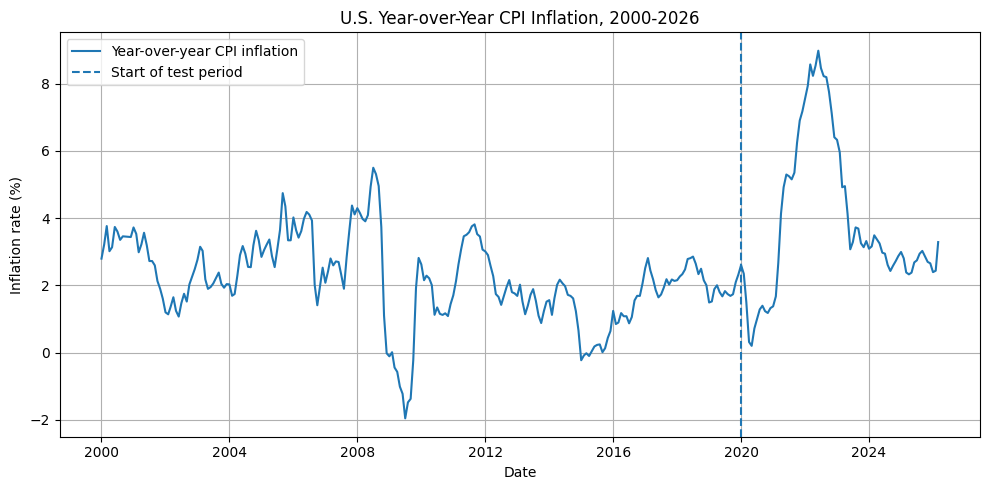

In [88]:
# Chart 1: Year-over-year inflation over time

plt.figure(figsize=(10, 5))
plt.plot(data["date"], data["inflation_yoy"], label="Year-over-year CPI inflation")
plt.axvline(pd.to_datetime("2020-01-01"), linestyle="--", label="Start of test period")
plt.title("U.S. Year-over-Year CPI Inflation, 2000-2026")
plt.xlabel("Date")
plt.ylabel("Inflation rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/inflation_over_time.png", dpi=300)
plt.show()

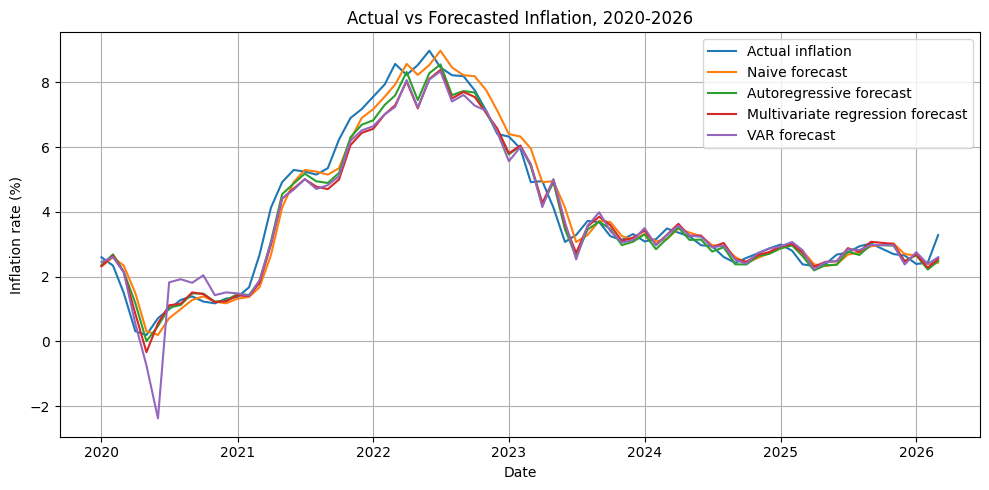

In [89]:

# Chart 2: Actual inflation vs model forecasts


plt.figure(figsize=(10, 5))

plt.plot(test["target_date"], test["inflation_next"], label="Actual inflation")
plt.plot(test["target_date"], test["naive_forecast"], label="Naive forecast")
plt.plot(test["target_date"], test["ar_forecast"], label="Autoregressive forecast")
plt.plot(test["target_date"], test["multi_forecast"], label="Multivariate regression forecast")
plt.plot(test["target_date"], test["var_forecast"], label="VAR forecast")

plt.title("Actual vs Forecasted Inflation, 2020-2026")
plt.xlabel("Date")
plt.ylabel("Inflation rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/actual_vs_forecasts.png", dpi=300)
plt.show()

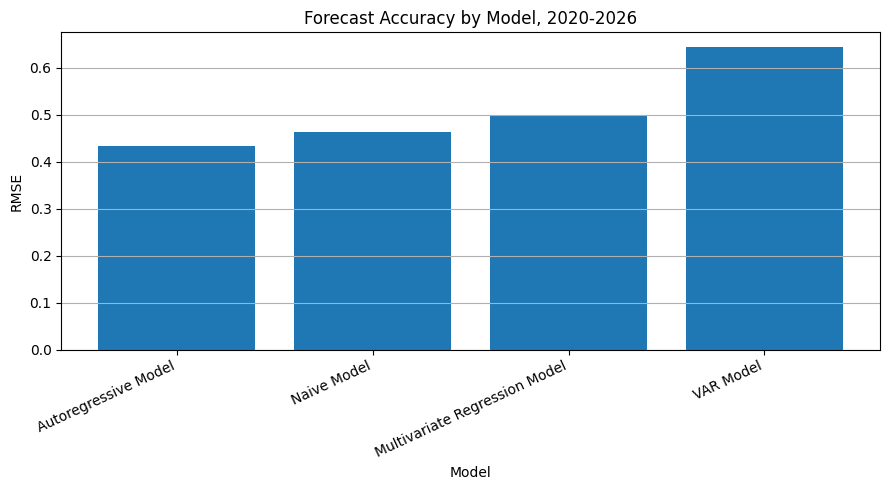

In [90]:

# Chart 3: Forecast accuracy comparison


plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Forecast Accuracy by Model, 2020-2026")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("outputs/model_accuracy_rmse.png", dpi=300)
plt.show()

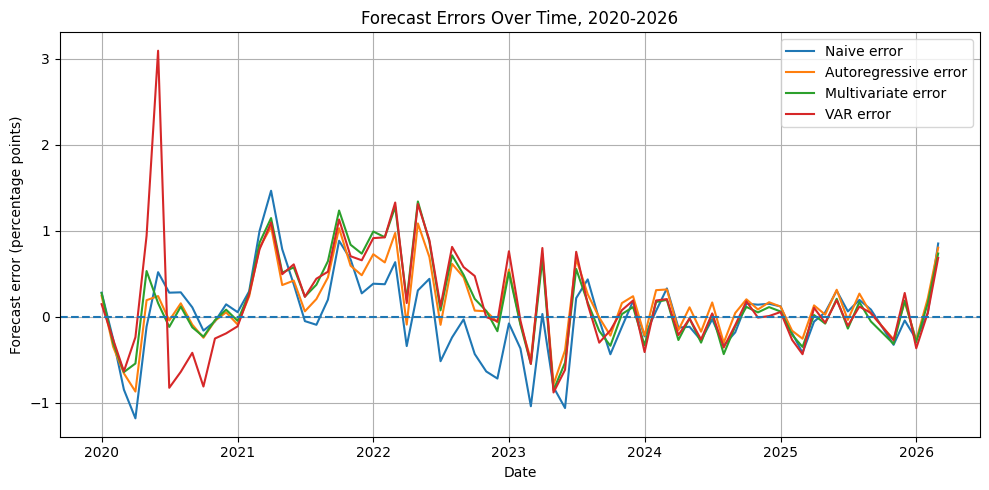

In [91]:

# Chart 4: Forecast errors over time


test["naive_error"] = test["inflation_next"] - test["naive_forecast"]
test["ar_error"] = test["inflation_next"] - test["ar_forecast"]
test["multi_error"] = test["inflation_next"] - test["multi_forecast"]
test["var_error"] = test["inflation_next"] - test["var_forecast"]

plt.figure(figsize=(10, 5))
plt.plot(test["target_date"], test["naive_error"], label="Naive error")
plt.plot(test["target_date"], test["ar_error"], label="Autoregressive error")
plt.plot(test["target_date"], test["multi_error"], label="Multivariate error")
plt.plot(test["target_date"], test["var_error"], label="VAR error")
plt.axhline(0, linestyle="--")
plt.title("Forecast Errors Over Time, 2020-2026")
plt.xlabel("Date")
plt.ylabel("Forecast error (percentage points)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/forecast_errors.png", dpi=300)
plt.show()

## 7. Did Forecasting Performance Change After 2020?

To answer the second part of the research question, model performance is compared across two periods:

- **2015–2019:** a pre-pandemic validation period
- **2020–2026:** the post-pandemic testing period

This comparison shows whether inflation became harder to forecast after 2020. If RMSE is higher after 2020, it means the models made larger forecast errors during the post-pandemic inflation period.

In [92]:

# Step 6: Compare model performance before and after 2020

# Split data into:
# Training period: 2000-2014
# Pre-pandemic validation period: 2015-2019
# Post-pandemic test period: 2020 onward

train_pre = model_data[model_data["target_date"] < "2015-01-01"]

validation_pre2020 = model_data[
    (model_data["target_date"] >= "2015-01-01") &
    (model_data["target_date"] < "2020-01-01")
]

test_post2020 = model_data[model_data["target_date"] >= "2020-01-01"]

print("Train pre shape:", train_pre.shape)
print("Pre-2020 validation shape:", validation_pre2020.shape)
print("Post-2020 test shape:", test_post2020.shape)

Train pre shape: (176, 12)
Pre-2020 validation shape: (60, 12)
Post-2020 test shape: (74, 12)


### Pre-2020 vs Post-2020 Accuracy Comparison

The following chart compares RMSE before and after 2020 for all four models. The goal is to see whether inflation became harder to forecast during the post-pandemic period.

Higher RMSE after 2020 means the model made larger forecast errors during the inflation surge.

In [93]:

# Pre-2020 vs Post-2020 forecast comparison

period_results = []

def evaluate_period_models(train_period, test_period, period_name):
    """
    Fits the naive, autoregressive, and multivariate regression models
    on train_period and evaluates them on test_period.
    """
    period_output = []

    # Naive model
    naive_pred = test_period["inflation_yoy"]
    period_output.append(evaluate_model(
        y_true=test_period["inflation_next"],
        y_pred=naive_pred,
        model_name=f"Naive Model - {period_name}"
    ))

    # Autoregressive model
    ar_model_period = LinearRegression()
    ar_model_period.fit(train_period[ar_features], train_period["inflation_next"])
    ar_pred = ar_model_period.predict(test_period[ar_features])
    period_output.append(evaluate_model(
        y_true=test_period["inflation_next"],
        y_pred=ar_pred,
        model_name=f"Autoregressive Model - {period_name}"
    ))

    # Multivariate regression model
    multi_model_period = LinearRegression()
    multi_model_period.fit(train_period[multi_features], train_period["inflation_next"])
    multi_pred = multi_model_period.predict(test_period[multi_features])
    period_output.append(evaluate_model(
        y_true=test_period["inflation_next"],
        y_pred=multi_pred,
        model_name=f"Multivariate Regression Model - {period_name}"
    ))

    return period_output


def evaluate_var_period(training_end_date, test_period, period_name):
    """
    Fits a VAR model before the period being evaluated and creates
    one-step-ahead inflation forecasts for that period.
    """
    var_variables = ["inflation_yoy", "UNRATE", "FEDFUNDS"]
    var_data = data[["date"] + var_variables].copy().set_index("date")

    # Fit VAR using only data before the evaluation period
    var_training_data = var_data[var_data.index < training_end_date]
    var_model_period = VAR(var_training_data[var_variables])
    var_results_period = var_model_period.fit(3)

    lag_order = var_results_period.k_ar
    var_forecasts = []

    for target_date in test_period["target_date"]:
        history = var_data[var_data.index < target_date][var_variables].tail(lag_order)
        forecast = var_results_period.forecast(y=history.values, steps=1)
        var_forecasts.append(forecast[0][0])

    return evaluate_model(
        y_true=test_period["inflation_next"],
        y_pred=var_forecasts,
        model_name=f"VAR Model - {period_name}"
    )


# Evaluate pre-2020 validation period
period_results.extend(
    evaluate_period_models(
        train_period=train_pre,
        test_period=validation_pre2020,
        period_name="2015-2019"
    )
)

period_results.append(
    evaluate_var_period(
        training_end_date="2015-01-01",
        test_period=validation_pre2020,
        period_name="2015-2019"
    )
)

# Evaluate post-2020 test period
period_results.extend(
    evaluate_period_models(
        train_period=train,
        test_period=test_post2020,
        period_name="2020-2026"
    )
)

period_results.append(
    evaluate_var_period(
        training_end_date="2020-01-01",
        test_period=test_post2020,
        period_name="2020-2026"
    )
)

period_results_df = pd.DataFrame(period_results)
period_results_df

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Model,MAE,RMSE
0,Naive Model - 2015-2019,0.203250,0.260906
1,Autoregressive Model - 2015-2019,0.201204,0.262687
2,Multivariate Regression Model - 2015-2019,0.200707,0.267486
3,VAR Model - 2015-2019,0.210148,0.264778
4,Naive Model - 2020-2026,0.343224,0.463410
5,Autoregressive Model - 2020-2026,0.330908,0.433864
6,Multivariate Regression Model - 2020-2026,0.374142,0.499515
7,VAR Model - 2020-2026,0.451186,0.642726


In [94]:
# Make comparison table easier to read
period_results_df["Base Model"] = period_results_df["Model"].str.replace(" - 2015-2019", "", regex=False)
period_results_df["Base Model"] = period_results_df["Base Model"].str.replace(" - 2020-2026", "", regex=False)

period_results_df["Period"] = period_results_df["Model"].apply(
    lambda x: "2015-2019" if "2015-2019" in x else "2020-2026"
)

period_comparison = period_results_df[["Base Model", "Period", "MAE", "RMSE"]]

period_comparison

,Base Model,Period,MAE,RMSE
0,Naive Model,2015-2019,0.203250,0.260906
1,Autoregressive Model,2015-2019,0.201204,0.262687
2,Multivariate Regression Model,2015-2019,0.200707,0.267486
3,VAR Model,2015-2019,0.210148,0.264778
4,Naive Model,2020-2026,0.343224,0.463410
5,Autoregressive Model,2020-2026,0.330908,0.433864
6,Multivariate Regression Model,2020-2026,0.374142,0.499515
7,VAR Model,2020-2026,0.451186,0.642726


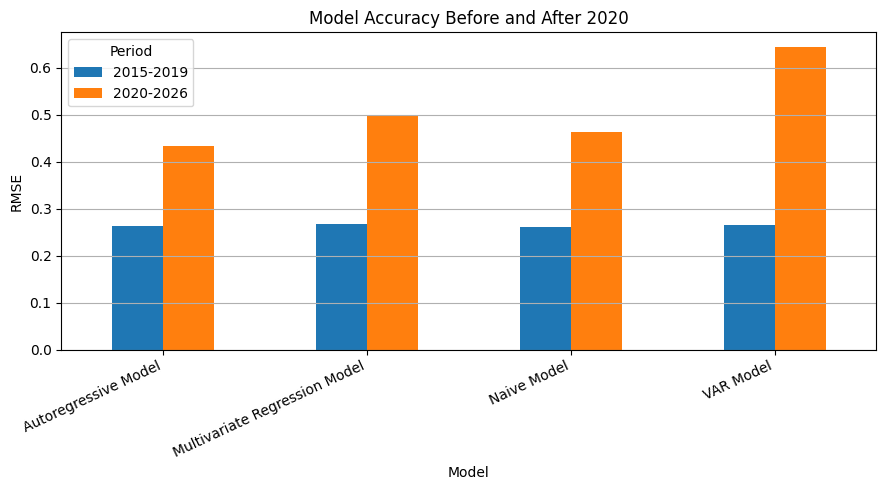

In [95]:

# Chart 5: Pre-2020 vs Post-2020 RMSE comparison

pivot_rmse = period_comparison.pivot(
    index="Base Model",
    columns="Period",
    values="RMSE"
)

pivot_rmse.plot(kind="bar", figsize=(9, 5))

plt.title("Model Accuracy Before and After 2020")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("outputs/pre_vs_post_rmse.png", dpi=300)
plt.show()

In [96]:
# Save pre-2020 vs post-2020 comparison
period_comparison.to_csv("outputs/pre_vs_post_model_comparison.csv", index=False)

period_comparison

,Base Model,Period,MAE,RMSE
0,Naive Model,2015-2019,0.203250,0.260906
1,Autoregressive Model,2015-2019,0.201204,0.262687
2,Multivariate Regression Model,2015-2019,0.200707,0.267486
3,VAR Model,2015-2019,0.210148,0.264778
4,Naive Model,2020-2026,0.343224,0.463410
5,Autoregressive Model,2020-2026,0.330908,0.433864
6,Multivariate Regression Model,2020-2026,0.374142,0.499515
7,VAR Model,2020-2026,0.451186,0.642726


## 8. Conclusion

The results show that inflation forecasting became more difficult after 2020. All models had higher forecast errors in the 2020–2026 period than in the 2015–2019 validation period.

During the post-2020 test period, the autoregressive model performed best because it had the lowest RMSE. This suggests that recent inflation history was more useful for predicting inflation than adding unemployment and federal funds rate variables.

The multivariate regression and VAR models did not improve forecast accuracy. One possible explanation is that the relationships between inflation, unemployment, and interest rates changed during the post-pandemic period. Supply chain disruptions, fiscal stimulus, energy price shocks, and delayed monetary policy responses may have made inflation harder to predict using conventional pre-pandemic relationships.

A possible extension would be to include additional variables such as oil prices, money growth, supply chain pressure indexes, or inflation expectations. Another extension would be to use rolling-window forecasts so the models can update more gradually over time.